In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request
from sklearn.decomposition import PCA

import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

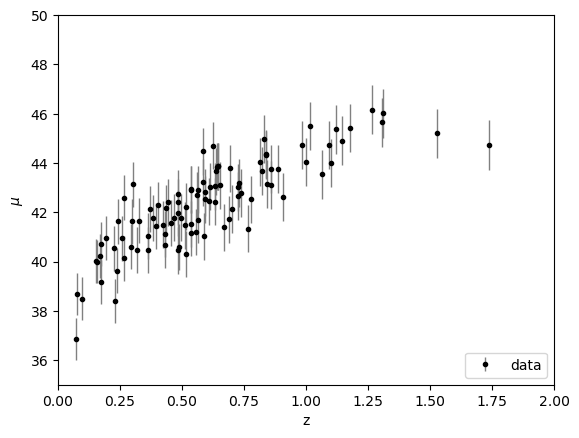

In [3]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [4]:
X = z_sample[:, np.newaxis]
y = mu_sample

Linear Regression
-

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=dmu)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print('Parameters from LinearRegression: q = %.2f, m = %.2f' % (theta0, theta1))

X_new = np.array([[min(z_sample)],[max(z_sample)]])
y_pred = theta0+theta1*X_new


Parameters from LinearRegression: q = 39.60, m = 4.59


/tmp/ipykernel_202049/3675041915.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Parameters from LinearRegression: q = %.2f, m = %.2f' % (theta0, theta1))


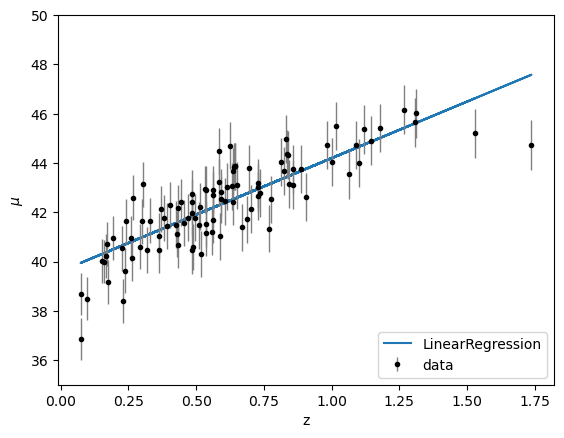

In [6]:
plt.plot(X[:,0],theta0+theta1*X[:,0],label='LinearRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50);

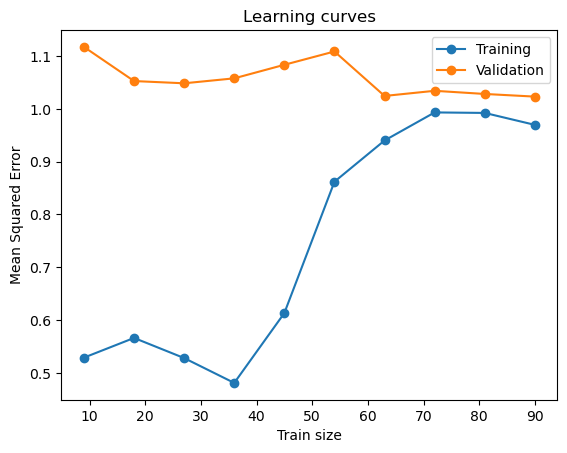

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

lin_reg = LinearRegression()
# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(lin_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', label="Training")
plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', label="Validation")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");
#plt.ylim(0,200)

#plt.show()

In [8]:
# Adding new data points should help (variance dominated)

Polynomial Regression
-

Parameters from PolynomialRegression with d = 5: [ 36.09081526  32.02899002 -73.25156852  87.69138092 -47.26697125
   9.15349892]


/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


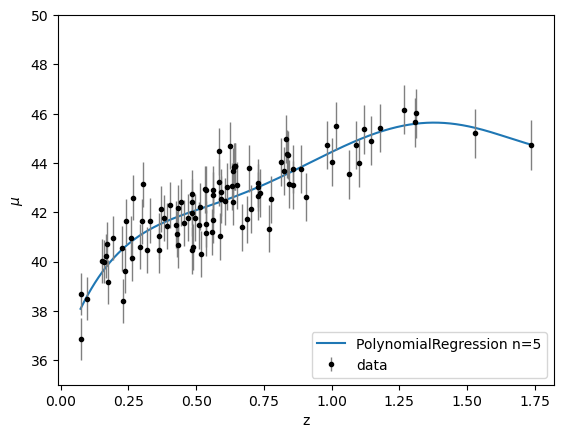

In [9]:
from astroML.linear_model import PolynomialRegression


degree = 5
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

theta = (model.coef_)
print('Parameters from PolynomialRegression with d = ' + str(degree) + ': ' + str(theta))

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50);

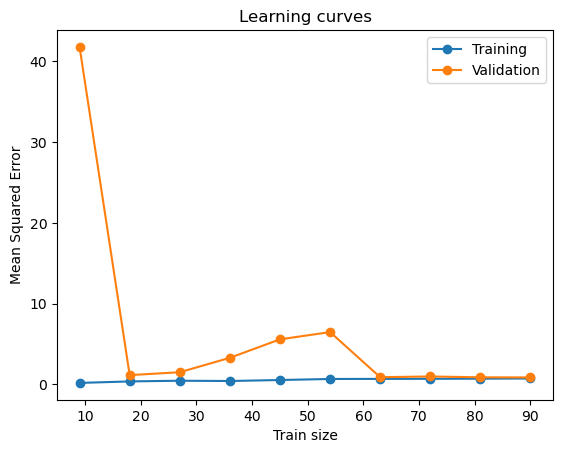

In [10]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(model, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', label="Training")
plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', label="Validation")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");
#plt.ylim(0,200)

#plt.show()

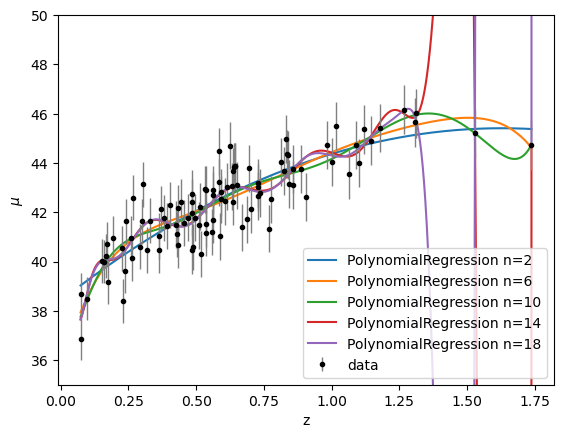

In [11]:
for n in np.arange(1,20)[1::4]:

    regressor = PolynomialRegression(n)
    regressor.fit(X, mu_sample, dmu)
    mu_fit = regressor.predict(X_test)
    plt.plot(X_test[:,0], mu_fit,label='PolynomialRegression n='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

Cross Validation on n in PolynomialRegression
-

In [12]:
dy = dmu

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [15]:
def geterror(X,y,classifier):
    return np.sqrt( np.sum(( y - classifier.predict(X) )**2) / len(X) )

def fitanderror(classifier):
    classifier.fit(X_train, y_train,dy_train)
    error_train = geterror(X_train,y_train,classifier)
    error_validation  = geterror(X_validation, y_validation, classifier)
    return error_train, error_validation

Polynomial Regression n = 1 1.0485115996674979 0.8238924629073958
Polynomial Regression n = 2 0.9385359114081161 0.8351995054159913
Polynomial Regression n = 3 0.9383899628086956 0.835411172564147
Polynomial Regression n = 4 0.9024072712440719 0.8095703348999901
Polynomial Regression n = 5 0.8924469328124864 0.8143335829739425
Polynomial Regression n = 6 0.8905028171949919 0.8113859054713811
Polynomial Regression n = 7 0.8699559684825303 0.8163407910202504
Polynomial Regression n = 8 0.8695867558751841 0.8211204495393384
Polynomial Regression n = 9 0.8696086089174182 0.821823452695699
Polynomial Regression n = 10 0.8666795023360166 0.8463777348693736
Polynomial Regression n = 11 0.8624581177722724 0.8513668728060229
Polynomial Regression n = 12 0.8558274202626077 0.8191597602129799
Polynomial Regression n = 13 0.8528955462267019 0.8247869300772835
Polynomial Regression n = 14 0.8407660005604881 0.8121593807792163
Polynomial Regression n = 15 0.838379287320327 0.8271903387358132
Polynom

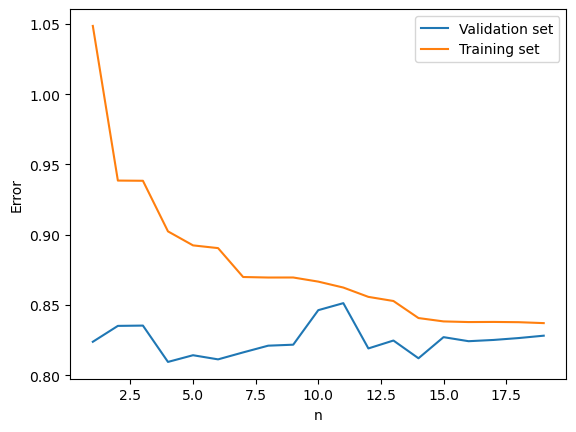

In [16]:
nrange = np.arange(1,20)

etrain, etest= [], []
for n in nrange:
    classifier = PolynomialRegression(n)
    error_train, error_validation = fitanderror(classifier)
    print("Polynomial Regression n =",n, error_train, error_validation)
    etrain.append(error_train)
    etest.append(error_validation)

plt.plot(nrange,etest, label='Validation set')
plt.plot(nrange,etrain, label='Training set')

plt.xlabel('n')
plt.ylabel('Error')
plt.legend()

print("Best", nrange[np.argmin(etest)], min(etest))

[ 36.95622821  21.50098389 -34.55444621  28.77101798  -8.39275909]


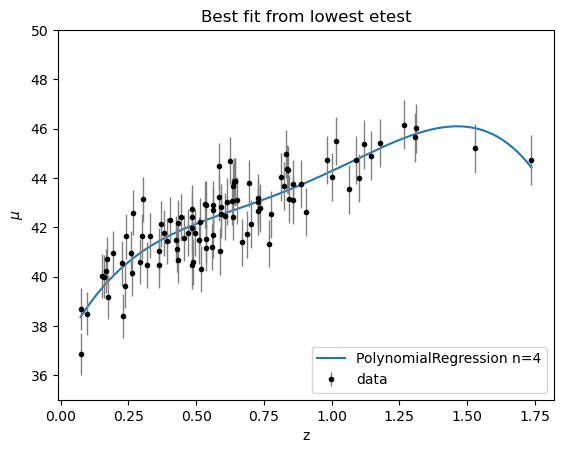

In [17]:
degree = nrange[np.argmin(etest)]
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.title('Best fit from lowest etest')
plt.ylim(35,50);

In [18]:
# CROSS VALIDATION

In [19]:
degrees = np.arange(1,20)

In [20]:
cv_scores = []

for i in range(len(degrees)):
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X, y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(
        pipeline, X, y, scoring='explained_variance',cv=5
    )
    cv_scores.append(scores.mean())
    

In [21]:
best_ind_cv = degrees[np.argmax(cv_scores)]

[38.41076899  8.59831905 -2.64090751]


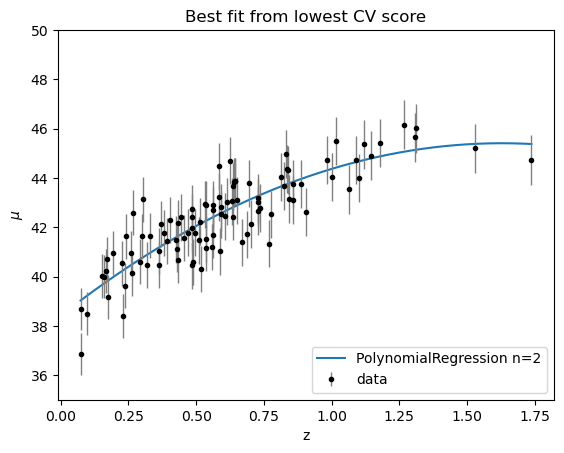

In [22]:
degree = best_ind_cv
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.title('Best fit from lowest CV score')
plt.ylim(35,50);

Basis Function Regression
-

Parameters from BasisFunctionRegression with gaussians: [33.84807677 -0.14234948  3.42530451 -0.91877242  4.07489771 -0.69715476
  4.55222575 -0.89089488  5.80454477 -1.38244442  5.12276597]


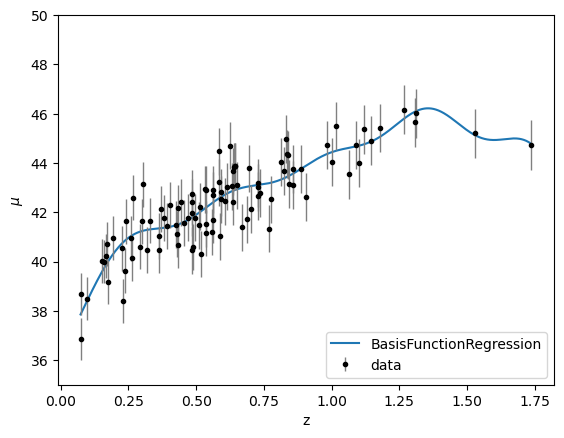

In [23]:
from astroML.linear_model import BasisFunctionRegression

# data

# mean positions of the 10 Gaussians in the model
X_gridtest = np.linspace(min(z_sample),max(z_sample),10)[:, None]
# widths of these Gaussians
sigma_test = (X_gridtest[1] - X_gridtest[0])

model = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model.fit(X, y, dmu)

y_pred = model.predict(X_test)
theta = (model.coef_)
print('Parameters from BasisFunctionRegression with gaussians: ' + str(theta))



plt.plot(X_test[:,0],y_pred,label='BasisFunctionRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

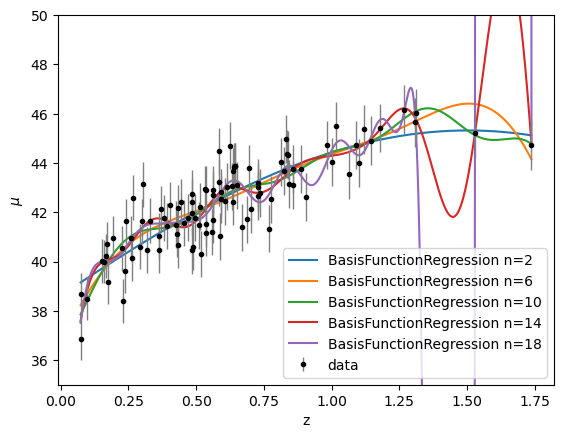

In [24]:
for n in np.arange(1,20)[1::4]:

    X_gridtest = np.linspace(min(z_sample),max(z_sample),n)[:, None]
    sigma_test = 1.0 * (X_gridtest[1] - X_gridtest[0])
    regressor = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
    regressor.fit(X, mu_sample, dmu)
    mu_fit = regressor.predict(X_test)
    plt.plot(X_test[:,0], mu_fit,label='BasisFunctionRegression n='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

Kernel Regression: Nadaraya-Watson
-

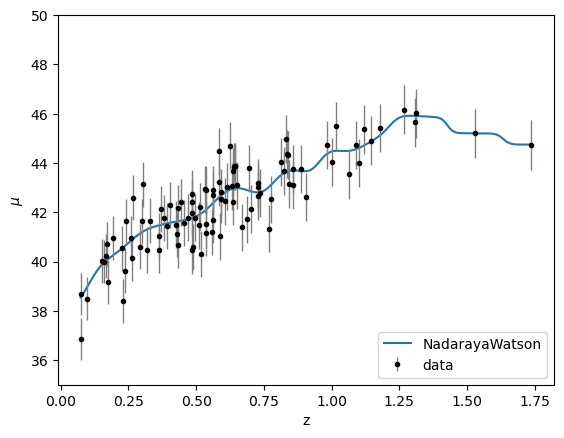

In [25]:
from astroML.linear_model import NadarayaWatson

model = NadarayaWatson(kernel='gaussian', h=0.05)
model.fit(X,y)

y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='NadarayaWatson')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

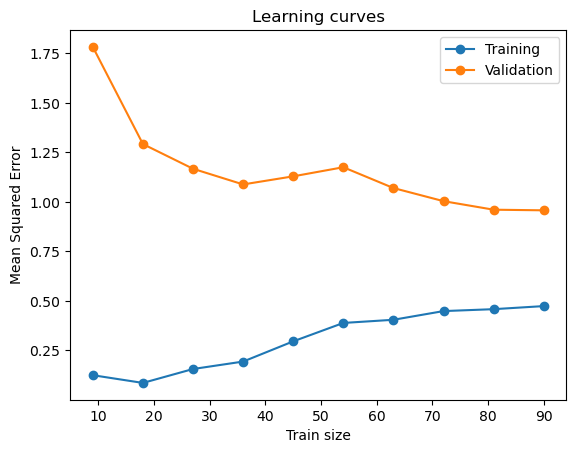

In [26]:


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(model, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', label="Training")
plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', label="Validation")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");
#plt.ylim(0,200)

#plt.show()

In [27]:
# Adding new data points should help (variance dominated) --> the model is too complex for the number of data